In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import pickle
import os
import time
from matplotlib.backends.backend_pdf import PdfPages


In [2]:
path_output = 'simulation_output/'
simulation_name_krig = os.listdir(path_output)[0:-1:2]
simulation_name = os.listdir(path_output)[1::2]

In [3]:
simulation_name_krig

['realisation0_krige.pickle',
 'realisation1_krige.pickle',
 'realisation2_krige.pickle',
 'realisation3_krige.pickle',
 'realisation4_krige.pickle',
 'realisation5_krige.pickle',
 'realisation6_krige.pickle',
 'realisation7_krige.pickle',
 'realisation8_krige.pickle',
 'realisation9_krige.pickle']

In [4]:
exec(open('./functions/05_indice_Calculation.py').read())

In [5]:
%xmode plain

Exception reporting mode: Plain


In [6]:
dirName ='simu_reports'
try:
    # Create target Directory
    os.mkdir(dirName)
    print("Directory " , dirName ,  " Created ") 
except FileExistsError:
    print("Directory " , dirName ,  " already exists")




all_output = []
type_sim = ['MPS1','MPS2','GRF','KRIG']
for name in simulation_name:
    pp = PdfPages(dirName +'/' + name+'.pdf')
    it = 0
    with open('simulation_output/'+name,'rb') as file:
        real_alt, simus_sets = pickle.load(file)
    
    with open('simulation_output/'+name[0:13]+'krige.pickle','rb') as file:
         real_k, krieg_sets = pickle.load(file)

    for simus in simus_sets:        
        pro = indice_calculation(real_alt,simus,'mps')
        all_output.append([name,type_sim[it]] + pro)
        it = it + 1
        
    pro = indice_calculation(real_k,krieg_sets,'krig')
    all_output.append([name,type_sim[it]] + pro)
    
results_frame = pd.DataFrame(data =all_output, columns=['Sim_name','Type','Error','Abs_error','Norm_Error','Mean','Sd'])


Directory  simu_reports  already exists


C:\Users\nevena\AppData\Local\Continuum\anaconda3\envs\Pyclass36\lib\site-packages\ipykernel_launcher.py:69: RuntimeWarning: divide by zero encountered in true_divide
C:\Users\nevena\AppData\Local\Continuum\anaconda3\envs\Pyclass36\lib\site-packages\ipykernel_launcher.py:69: RuntimeWarning: invalid value encountered in true_divide
C:\Users\nevena\AppData\Local\Continuum\anaconda3\envs\Pyclass36\lib\site-packages\ipykernel_launcher.py:36: RuntimeWarning: invalid value encountered in true_divide


In [ ]:
results_frame[results_frame['Type']=='KRIG']

In [ ]:
len(simus_sets[0])

In [ ]:
plt.subplots(1,2,figsize=(5,5))
plt.subplot(1,2,3)

In [ ]:
real_alt.shape

In [ ]:
plt.imshow(all_output[3][3])

In [ ]:
pts_0 = [elt[0] for elt in all_output]
pts_1 = [elt[1] for elt in all_output]
pts_2 = [elt[2] for elt in all_output]


plt.plot(pts_0,color='tan')
plt.plot(pts_1)
plt.plot(pts_2)
plt.legend(['error','abs_error','norm_error'])
plt.plot(np.ones(len(pts_0))*2,color='grey',ls='--')
#plt.plot(pts[2])
#plt.plot(pts[0])

Text(0, 0.5, 'Error [m]')

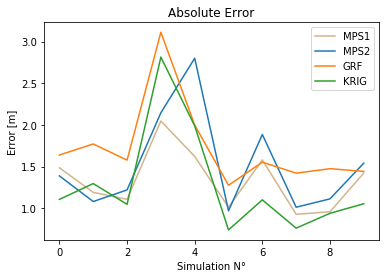

In [7]:
plt.plot(results_frame[results_frame['Type']=='MPS1'].Abs_error.values,color='tan')
plt.plot(results_frame[results_frame['Type']=='MPS2'].Abs_error.values)
plt.plot(results_frame[results_frame['Type']=='GRF'].Abs_error.values)
plt.plot(results_frame[results_frame['Type']=='KRIG'].Abs_error.values)
plt.legend(['MPS1','MPS2','GRF','KRIG'])
plt.title('Absolute Error')
plt.xlabel('Simulation N°')
plt.ylabel('Error [m]')
#plt.plot(np.ones(len(pts_0))*2,color='grey',ls='--')


Text(0, 0.5, 'Error [m]')

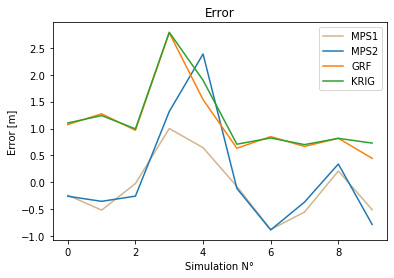

In [8]:
plt.plot(results_frame[results_frame['Type']=='MPS1'].Error.values,color='tan')
plt.plot(results_frame[results_frame['Type']=='MPS2'].Error.values)
plt.plot(results_frame[results_frame['Type']=='GRF'].Error.values)
plt.plot(results_frame[results_frame['Type']=='KRIG'].Error.values)
plt.legend(['MPS1','MPS2','GRF','KRIG'])
plt.title('Error')
plt.xlabel('Simulation N°')
plt.ylabel('Error [m]')

#plt.plot(np.ones(len(pts_0))*0,color='grey',ls='--')

Text(0, 0.5, 'Error [m]')

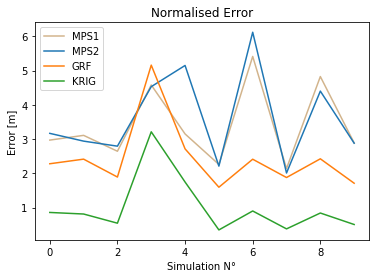

In [9]:
plt.plot(results_frame[results_frame['Type']=='MPS1'].Norm_Error.values,color='tan')
plt.plot(results_frame[results_frame['Type']=='MPS2'].Norm_Error.values)
plt.plot(results_frame[results_frame['Type']=='GRF'].Norm_Error.values)
plt.plot(results_frame[results_frame['Type']=='KRIG'].Norm_Error.values)
plt.legend(['MPS1','MPS2','GRF','KRIG'])
plt.title('Normalised Error')
plt.xlabel('Simulation N°')
plt.ylabel('Error [m]')
#plt.plot(np.ones(len(pts_0))*1,color='grey',ls='--')

In [ ]:
a = results_frame[results_frame['Type']=='MPS1'].Abs_error.values

In [ ]:
a